# Supervised Machine Learning — Car Prediction Model By Regression

## Table of Contents
1. [Introduction & Setup](#1)
2. [Exploratory Data Analysis](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Feature Engineering](#4)
5. [Train-Test Split](#5)
6. [Baseline Model](#6)
7. [Model Building](#7)
8. [Hyperparameter Tuning](#8)
9. [Model Evaluation](#9)
10. [Model Interpretation](#10)
11. [Final Model Selection & Testing](#11)



<a id="1"></a>
## 1. Introduction & Setup

### 1.1 Project Overview & Objectives

The objective of this project is to train a model to learn from the data provided from kaggle to predict the car selling prices influenced by the different features like mileage, year ,transmission,selling type. e.t.c


### 1.2 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
pip install shap --break-system-packages

### 1.3 Load Data

In [3]:
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")

print("Path to dataset files:", path)
print("Files in dataset directory:", os.listdir(path))


df = pd.read_csv(path +'/car data.csv')
TARGET_COLUMN = 'Selling_Price'
df.head()

100%|██████████| 3.76k/3.76k [00:00<00:00, 6.52MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vijayaadithyanvg/car-price-predictionused-cars/versions/1
Files in dataset directory: ['car data.csv']


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


<a id="2"></a>
## 2. Exploratory Data Analysis (EDA)

### 2.1 Data Overview

In [4]:
print(df.shape)
df.info()

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


### 2.2 Summary Statistics

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### 2.3 Missing Value Analysis

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0


### 2.4 Target Variable Distribution

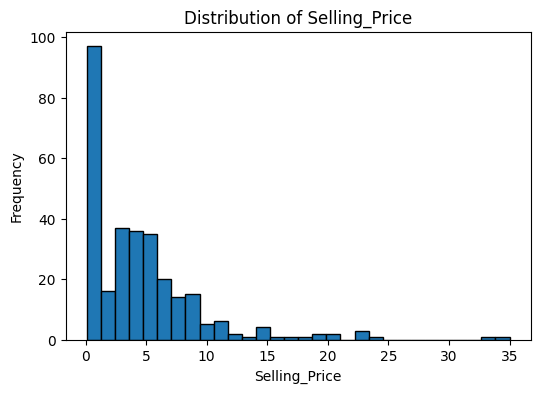

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df[TARGET_COLUMN], bins=30, edgecolor='black')
plt.title(f"Distribution of {TARGET_COLUMN}")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Frequency")
plt.show()

### 2.5 Univariate Analysis (feature distributions)

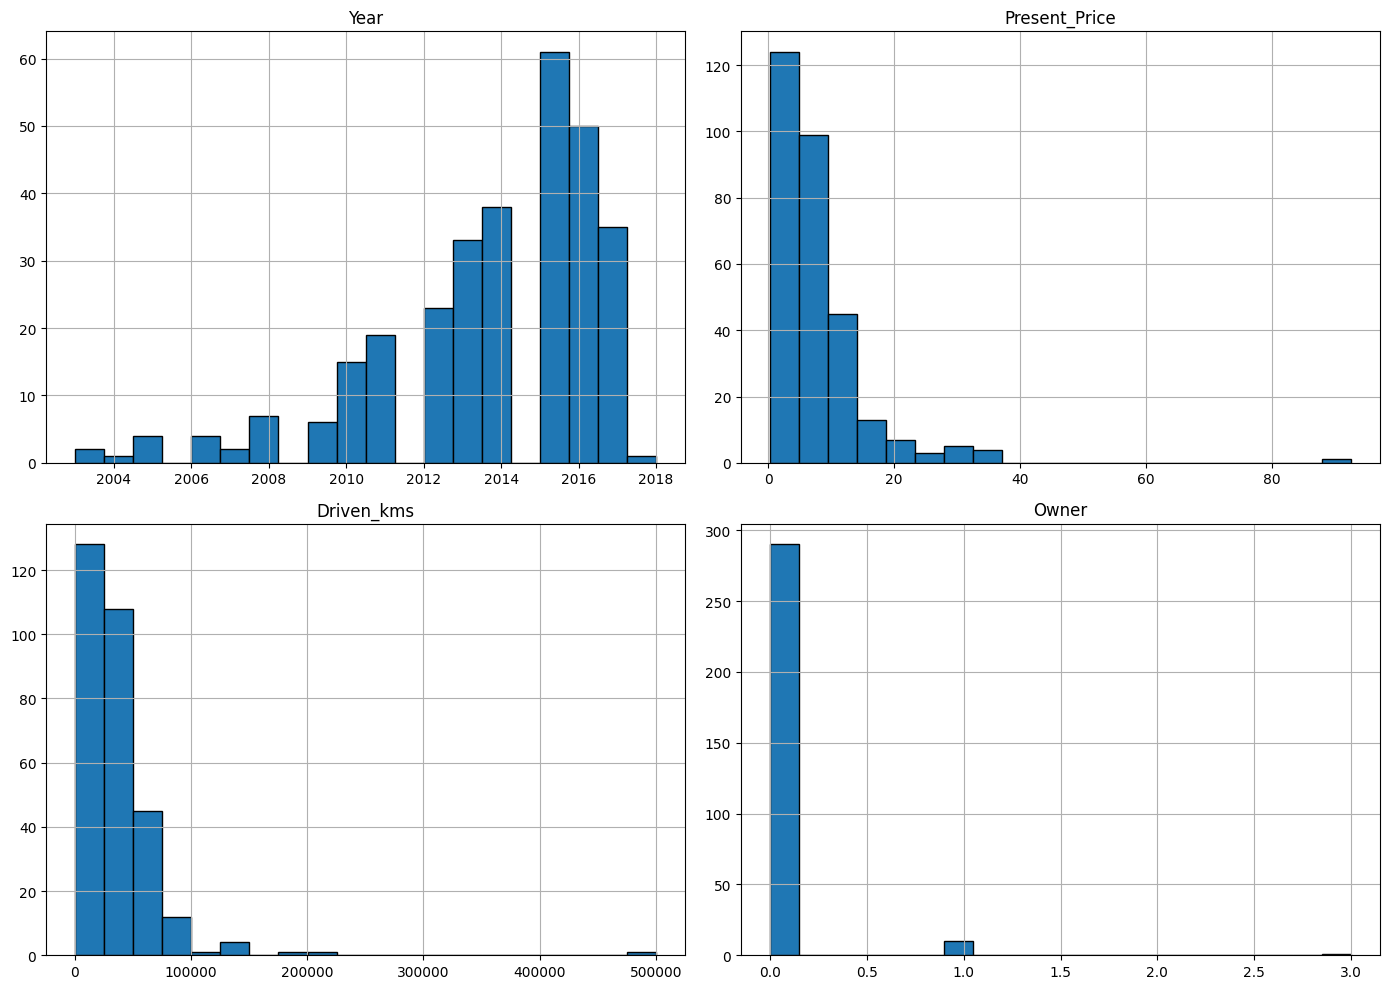

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop(TARGET_COLUMN, errors='ignore')

df[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


### 2.6 Bivariate Analysis (feature vs. target)

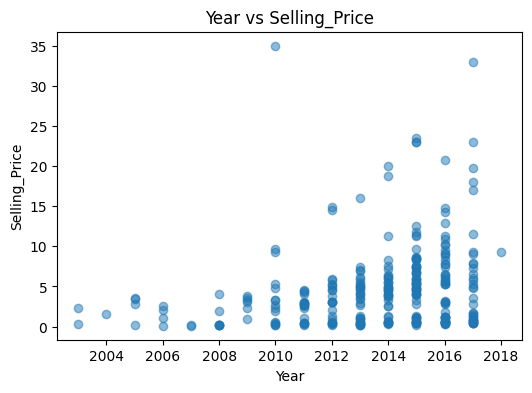

In [9]:
feature_name = numeric_cols[0]

plt.figure(figsize=(6,4))
plt.scatter(df[feature_name], df[TARGET_COLUMN], alpha=0.5)
plt.xlabel(feature_name)
plt.ylabel(TARGET_COLUMN)
plt.title(f"{feature_name} vs {TARGET_COLUMN}")
plt.show()


### 2.7 Correlation Analysis / Heatmap

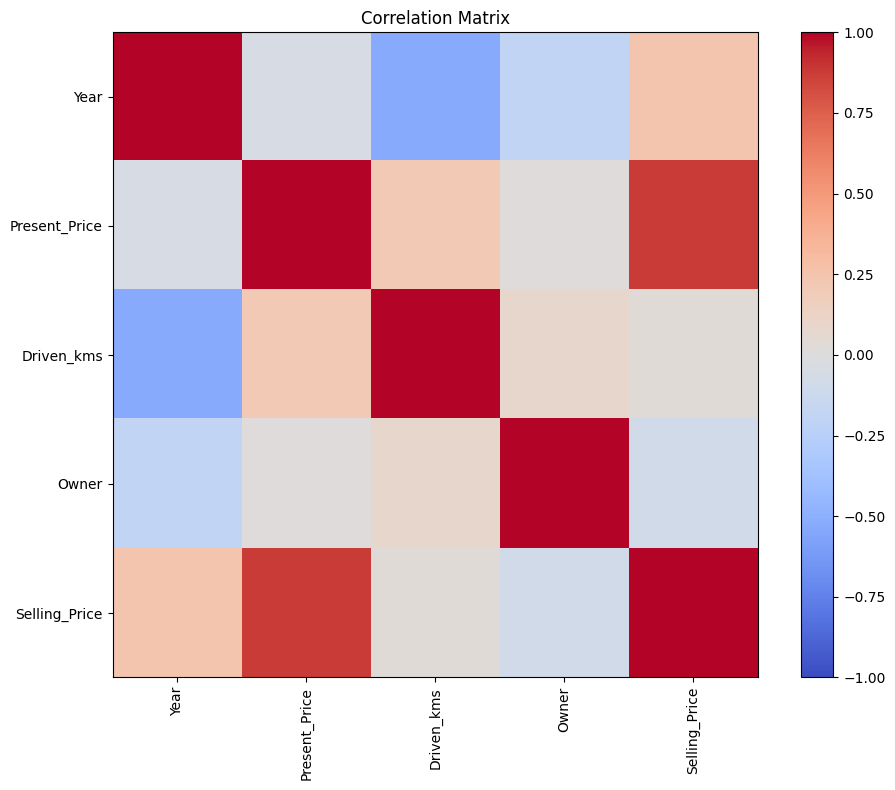

In [10]:
corr = df[numeric_cols.tolist() + [TARGET_COLUMN]].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### 2.8 Outlier Detection

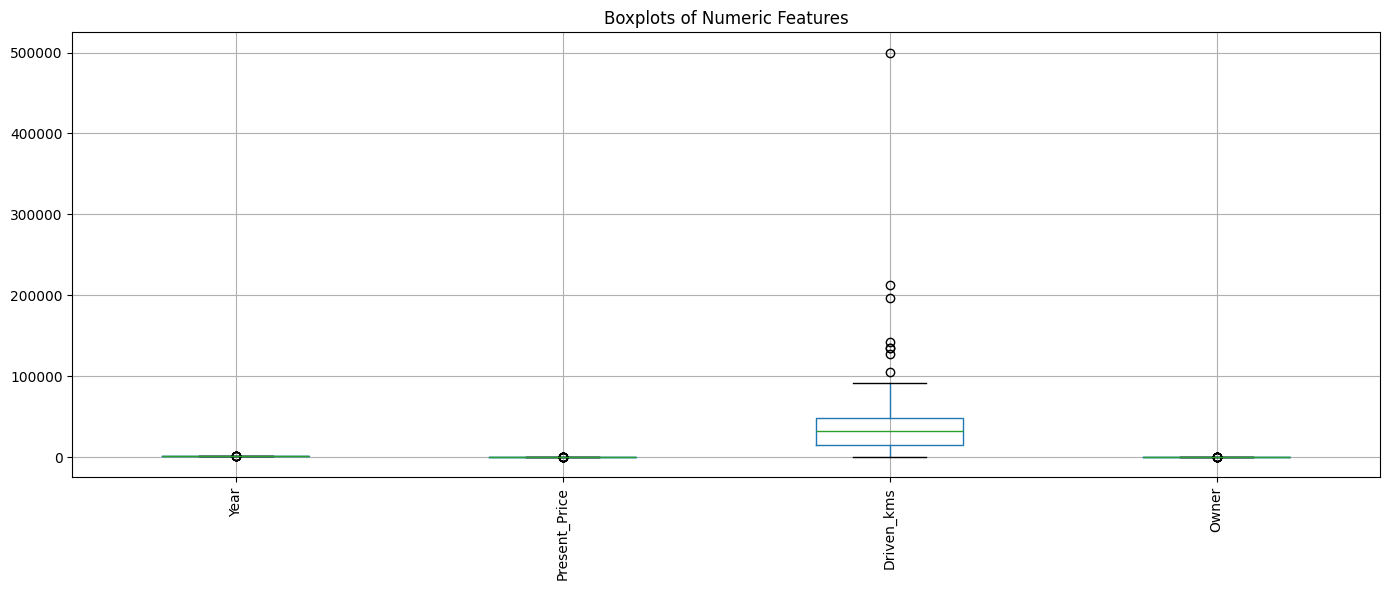

In [11]:
plt.figure(figsize=(14, 6))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots of Numeric Features")
plt.tight_layout()
plt.show()


<a id="3"></a>
## 3. Data Cleaning & Preprocessing

### 3.1 Handling Missing Values

In [12]:

threshold = 0.5
cols_to_drop = missing[missing / len(df) > threshold].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")


Dropped columns: []


### 3.2 Handling Outliers

In [13]:

def cap_outliers_iqr(series, factor=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower, upper)


### 3.3 Duplicate Removal

In [14]:
print(f"Duplicates found: {df.duplicated().sum()}")
df = df.drop_duplicates()


Duplicates found: 2


### 3.4 Data Type Conversions

In [15]:

df.dtypes


,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64


<a id="4"></a>
## 4. Feature Engineering

### 4.1 Feature Creation / Transformation

In [16]:

df['Year']=2026-df['Year']
df.head()



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,12,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,13,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,9,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,15,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,12,4.60,6.87,42450,Diesel,Dealer,Manual,0


### 4.2 Encoding Categorical Variables

In [17]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_features = df.select_dtypes(include=np.number).columns.drop(TARGET_COLUMN, errors='ignore').tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_features)


Categorical columns: ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']
Numeric columns: ['Year', 'Present_Price', 'Driven_kms', 'Owner']


### 4.3 Feature Scaling & Preprocessing Pipeline

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_cols)
])


<a id="5"></a>
## 5. Train-Test Split

In [19]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (239, 8), Test shape: (60, 8)


<a id="6"></a>
## 6. Baseline Model

In [20]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])

baseline_pipeline.fit(X_train, y_train)
baseline_preds = baseline_pipeline.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, baseline_preds))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_preds)))
print("Baseline R2:", r2_score(y_test, baseline_preds))

Baseline MAE: 3.3269470013947005
Baseline RMSE: 5.076823950394027
Baseline R2: -3.411291378685455e-05


<a id="7"></a>
## 7. Model Building

### 7.1 - 7.2 Model Selection & Training

In [21]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RandomForest': RandomForestRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

pd.DataFrame(results).T


,MAE,RMSE,R2
LinearRegression,1.436092,2.653277,0.726853
Ridge,1.344409,2.384950,0.779307
RandomForest,1.390835,3.383141,0.555910


### 7.3 Cross-Validation

In [22]:
cv_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])
cv_scores = cross_val_score(cv_pipe, X_train, y_train, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


CV R2 scores: [0.75249368 0.97595579 0.76706688 0.96741747 0.97310942]
Mean CV R2: 0.8872086494476417


<a id="8"></a>
## 8. Hyperparameter Tuning

In [23]:
param_grid = {
    'regressor__n_estimators': [100, 200, 400],
    'regressor__max_depth': [None, 5, 10, 20],
    'regressor__min_samples_leaf': [1, 2, 4]
}

tuning_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))])

grid_search = GridSearchCV(
    tuning_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

best_model = grid_search.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 400}
Best CV R2: 0.8911218073773414


<a id="9"></a>
## 9. Model Evaluation

### 9.1 Performance Metrics

In [24]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")


MAE:  1.3689
RMSE: 3.2571
R2:   0.5884


### 9.2 Residual Plots

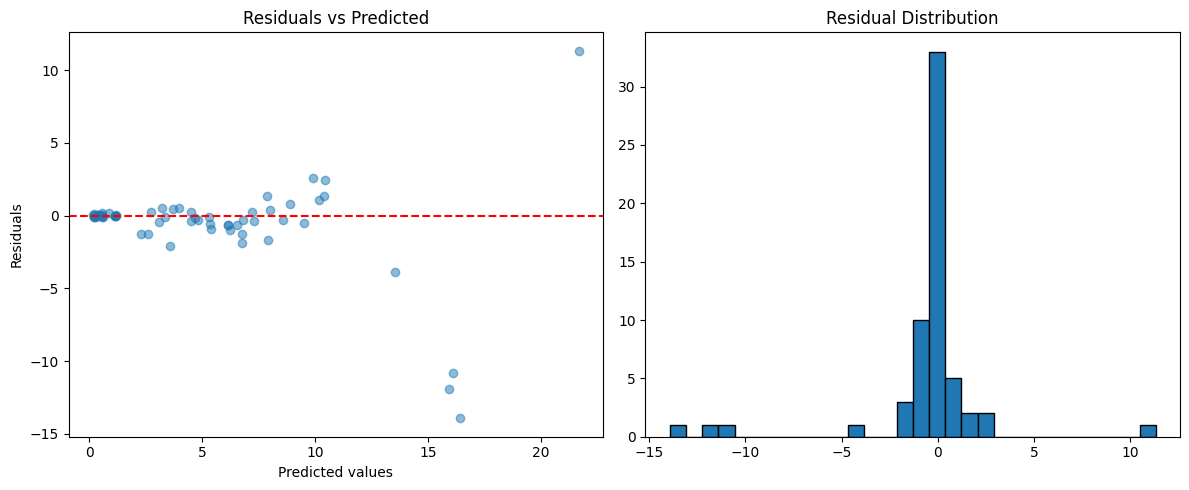

In [25]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


### 9.3 Learning Curves

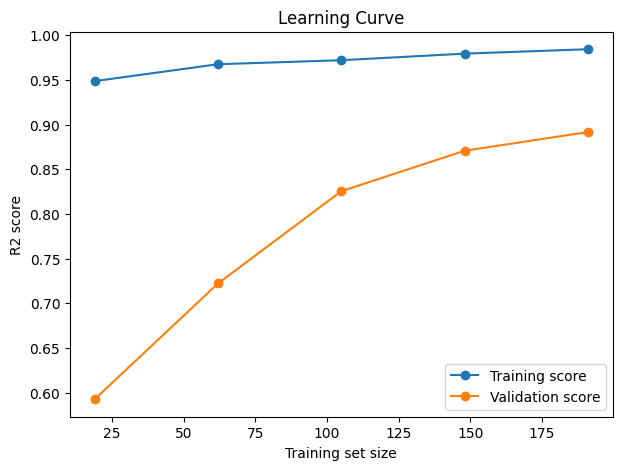

In [26]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.xlabel("Training set size")
plt.ylabel("R2 score")
plt.title("Learning Curve")
plt.legend()
plt.show()


### 9.4 Comparison of Multiple Models

In [27]:
pd.DataFrame(results).T.sort_values('R2', ascending=False)

,MAE,RMSE,R2
Ridge,1.344409,2.384950,0.779307
LinearRegression,1.436092,2.653277,0.726853
RandomForest,1.390835,3.383141,0.555910


<a id="10"></a>
## 10. Model Interpretation

### 10.1 Feature Importance

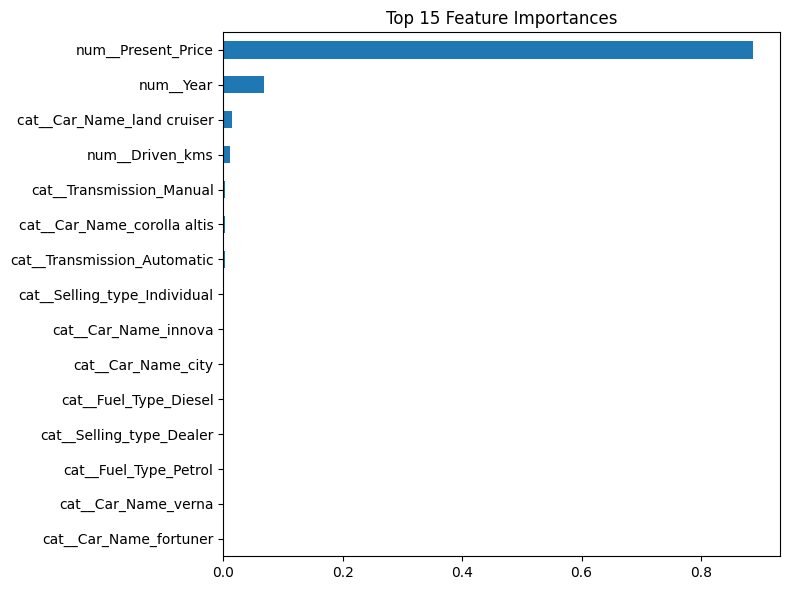

In [28]:
regressor = best_model.named_steps['regressor']
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = pd.Series(regressor.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


### 10.2 SHAP Analysis

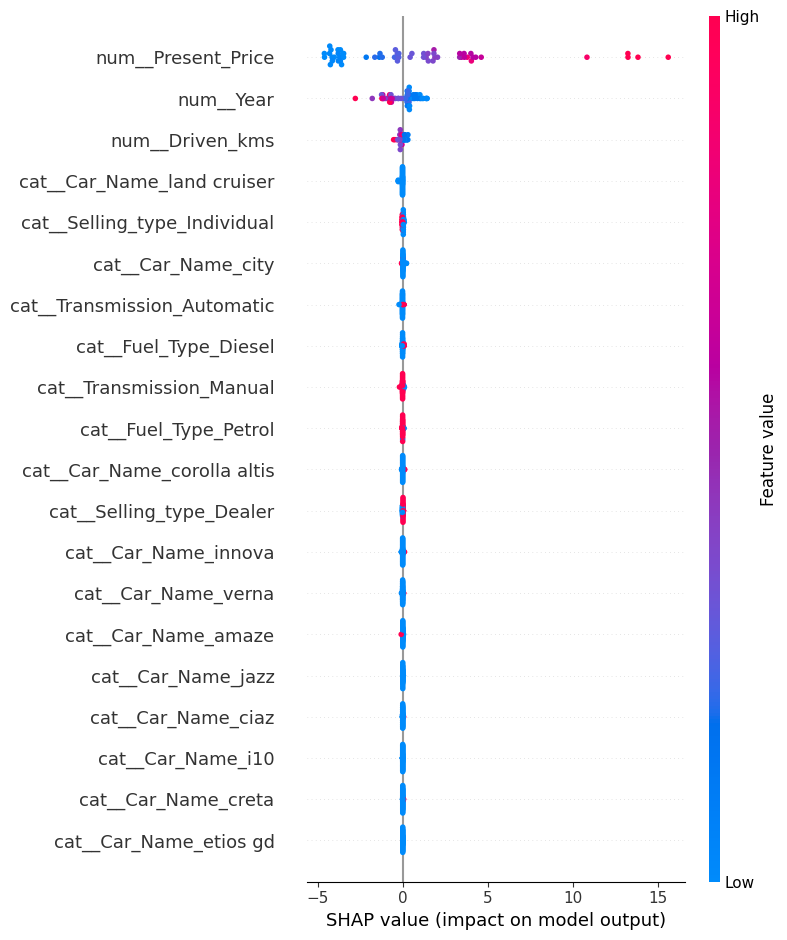

In [29]:
import shap
explainer = shap.TreeExplainer(regressor)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)


if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()


X_test_transformed = X_test_transformed.astype(float)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

<a id="11"></a>
## 11. Final Model Selection & Testing

### 11.1  Final Evaluation on Test Set

In [30]:
print("Final model performance on held-out test set:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")


Final model performance on held-out test set:
MAE:  1.3689
RMSE: 3.2571
R2:   0.5884


### 11.2 Error Analysis

In [31]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = y_pred
error_df['abs_error'] = np.abs(error_df['actual'] - error_df['predicted'])

error_df.sort_values('abs_error', ascending=False).head(10)


,Car_Name,Year,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,actual,predicted,abs_error
85,camry,20,23.73,142000,Petrol,Individual,Automatic,3,2.50,16.429925,13.929925
94,corolla altis,18,22.78,89000,Petrol,Dealer,Automatic,0,4.00,15.913850,11.913850
64,fortuner,9,36.23,6000,Diesel,Dealer,Automatic,0,33.00,21.670175,11.329825
78,corolla altis,16,22.83,80000,Petrol,Dealer,Automatic,0,5.25,16.096725,10.846725
99,fortuner,16,20.45,50024,Diesel,Dealer,Manual,0,9.65,13.541275,3.891275
83,innova,11,13.46,38000,Diesel,Dealer,Manual,0,12.50,9.896350,2.603650
250,creta,10,13.60,35934,Diesel,Dealer,Manual,0,12.90,10.430550,2.469450
77,corolla,22,12.35,135154,Petrol,Dealer,Automatic,0,1.50,3.595250,2.095250
74,etios cross,12,8.93,83000,Diesel,Dealer,Manual,0,4.90,6.772375,1.872375
279,city,12,13.60,40126,Petrol,Dealer,Manual,0,6.25,7.907050,1.657050
